# Modeling Home Prices (Ames) with Linear Regression and Regularization (Ridge & LASSO)

This project models residential sale prices using the Ames Housing dataset, inspired by Zillow's Zestimate and the failure of Zillow Offers during the COVID-19 pandemic. Zillow's algorithm was trained on pre-pandemic data but deployed in a very different market—a classic case of **data drift** (distribution mismatch between training and real-world data). The goal is to build interpretable linear models (OLS, then **Ridge** and **LASSO**), evaluate them using out-of-sample R² (OSR²) and RMSE, and discuss the risk of deploying such models when the data distribution shifts.

We use the **Ames Housing** dataset (Ames, Iowa, 2006–2010). The target is **Log(Sale Price)**; features include zoning, dwelling type, year built, neighborhood, square footage, and many other property and sale characteristics. The notebook demonstrates preprocessing, train/test split, model fitting with scikit-learn and statsmodels, evaluation, and the value of regularization when OLS overfits.

In [ ]:
# import files and mute the warnings
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data and Explore Structure

We begin by loading the cleaned Ames dataset (Ames_clean.csv), which contains residential property sales in Ames, Iowa from 2006–2010. We inspect its shape and columns to understand the structure of the data.


In [84]:
#read_data
ames = pd.read_csv('Ames_clean.csv')
ames.info()

In [85]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
ames.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 189 entries, MSSubClass to GarageCond_nan
dtypes: bool(102), float64(32), int64(26), object(29)
memory usage: 2.2+ MB


## 2. Preprocessing

We encode remaining categorical variables with `get_dummies`, convert booleans to 0/1, and check for missing values so the data are suitable for regression.

In [87]:
# Handle remaining categorical variables 
categorical_cols = ames.columns[ames.dtypes == 'object']
for col in categorical_cols:
    print(col, ':\n', ames[col].unique())
ames = pd.get_dummies(ames, columns=categorical_cols)

MSZoning :
 ['RL' 'RH' 'FV' 'RM' 'C' 'I' 'A']
Street :
 ['Pave' 'Grvl']
Alley :
 ['NoAccess' 'Pave' 'Grvl']
LotShape :
 ['IR1' 'Reg' 'IR2' 'IR3']
LandContour :
 ['Lvl' 'HLS' 'Bnk' 'Low']
Utilities :
 ['AllPub' 'NoSewr' 'NoSeWa']
LotConfig :
 ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
LandSlope :
 ['Gtl' 'Mod' 'Sev']
Neighborhood :
 ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']
BldgType :
 ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']
HouseStyle :
 ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']
RoofStyle :
 ['Hip' 'Gable' 'Mansard' 'Gambrel' 'Shed' 'Flat']
RoofMatl :
 ['CompShg' 'WdShake' 'Tar&Grv' 'WdShngl' 'Membran' 'ClyTile' 'Roll'
 'Metal']
ExterQual :
 ['TA' 'Gd' 'Ex' 'Fa']
ExterCond :
 ['TA' 'Gd' 'Fa' 'Po' 'Ex']
Foundation :
 ['CBlock

In [88]:
# Converting True/False to 1/0
ames= ames.replace({True: 1, False: 0})

In [89]:
# Checking for NA values
print(np.sum(ames.isnull().any()))

0


In [76]:
ames.head()

,MSSubClass,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,X1stFlrSF,X2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,LogSalePrice,Artery,Feedr,PosA,PosB,RRAe,RRAn,RRNn,RRNe,ExteriorAsbShng,ExteriorAsphShn,ExteriorBrkComm,ExteriorBrkFace,ExteriorCBlock,ExteriorCemntBd,ExteriorHdBoard,ExteriorImStucc,ExteriorMetalSd,ExteriorPlywood,ExteriorPreCast,ExteriorStone,ExteriorStucco,ExteriorVinylSd,ExteriorWdSdng,ExteriorWdShing,ExteriorOther,YearsSince1950Built,YearsSince1950Remod,YearsSince1950GarageBuilt,YrSold_2006.0,YrSold_2007.0,YrSold_2008.0,YrSold_2009.0,YrSold_2010.0,MoSold_1.0,MoSold_2.0,MoSold_3.0,MoSold_4.0,MoSold_5.0,MoSold_6.0,MoSold_7.0,MoSold_8.0,MoSold_9.0,MoSold_10.0,MoSold_11.0,MoSold_12.0,OverallQual_1,OverallQual_2,OverallQual_3,OverallQual_4,OverallQual_5,OverallQual_6,OverallQual_7,OverallQual_8,OverallQual_9,OverallQual_10,OverallCond_1,OverallCond_2,OverallCond_3,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_CBlock,MasVnrType_Stone,MasVnrType_nan,BsmtQual_Ex,...,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Po,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_NoFirePlace,FireplaceQu_Po,FireplaceQu_TA,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_NoGarage,PavedDrive_N,PavedDrive_P,PavedDrive_Y,PoolQC_Ex,PoolQC_Fa,PoolQC_Gd,PoolQC_NoPool,PoolQC_TA,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NoFence,MiscFeature_Elev,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_VWD,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,141.0,31770.0,112.0,639.0,0.0,441.0,1080.0,1656.0,0.0,0.0,1656.0,1.0,0.0,1.0,0.0,3.0,1.0,7.0,2.0,2.0,528.0,210.0,62.0,0.0,0.0,0.0,0.0,0.0,12.278393,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,10.0,10.0,10.0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,20,80.0,11622.0,0.0,468.0,144.0,270.0,882.0,896.0,0.0,0.0,896.0,0.0,0.0,1.0,0.0,2.0,1.0,5.0,0.0,1.0,730.0,140.0,0.0,0.0,0.0,120.0,0.0,0.0,11.561716,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,11.0,11.0,11.0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,20,81.0,14267.0,108.0,923.0,0.0,406.0,1329.0,1329.0,0.0,0.0,1329.0,0.0,0.0,1.0,1.0,3.0,1.0,6.0,0.0,1.0,312.0,393.0,36.0,0.0,0.0,0.0,0.0,12500.0,12.055250,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

## 3. Train–Test Split

Following good practice for time-based evaluation, we split the dataset chronologically: training on sales from 2006–2008 and testing on 2009–2010. Setting aside the most recently observed data for the test set mimics the risk of data drift when a model trained on one period is deployed in another.

In [90]:
yrsold_cols = [col for col in ames.columns if "YrSold" in col]

print("YrSold columns:")
print(yrsold_cols)

YrSold columns:
['YrSold_2006.0', 'YrSold_2007.0', 'YrSold_2008.0', 'YrSold_2009.0', 'YrSold_2010.0']


In [91]:
## split by year sold
ames_train = ames[(ames['YrSold_2006.0'] == 1) | (ames['YrSold_2007.0'] == 1) | (ames['YrSold_2008.0'] == 1)]
ames_test = ames[(ames['YrSold_2009.0'] == 1) | (ames['YrSold_2010.0'] == 1)]

print(ames.shape, ames_train.shape, ames_test.shape)

(2930, 334) (1941, 334) (989, 334)


### Get the X and y matrices

We define the target (Log Sale Price) and feature matrix for train and test sets.

In [92]:
y_train = ames_train['LogSalePrice']
y_test = ames_test['LogSalePrice']

X_train = ames_train.drop(columns='LogSalePrice')
X_test = ames_test.drop(columns='LogSalePrice')

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1941, 333) (1941,) (989, 333) (989,)


## 4. Baseline: Ordinary Least Squares (OLS)

We fit an OLS model on the training data using a design matrix with a constant (intercept), then inspect the summary for fit and multicollinearity warnings.

In [93]:
import statsmodels.api as sm

X_train_lr = sm.add_constant(X_train, prepend=True, has_constant='add')
X_test_lr = sm.add_constant(X_test, prepend=True, has_constant='add')

lr = sm.OLS(y_train, X_train_lr).fit()

print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     123.7
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:50:20   Log-Likelihood:                 1974.7
No. Observations:                1941   AIC:                            -3401.
Df Residuals:                    1667   BIC:                            -1875.
Df Model:                         273                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## 5. Evaluation Metrics (OSR² and RMSE)

We evaluate predictions on the test set using out-of-sample R² (OSR²) and RMSE. These metrics show how well the model generalizes beyond the training data.

In [94]:
def OSR2(y_train, y_test, y_pred):
    
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(y_train))**2)
                 
    return (1 - SSE/SST)

In [95]:
def RMSE(y_test, y_pred):
    
    return np.sqrt(np.mean((y_test - y_pred)**2))

In [96]:
def print_metrics(model, X_train, y_train, X_test, y_test, flag_log_sale_price=False):

    if (flag_log_sale_price == True):
        
        y_pred_train = pd.Series(model.predict(X_train)).reset_index(drop=True)
        y_pred_test = pd.Series(model.predict(X_test)).reset_index(drop=True)
        y_train = y_train.copy().reset_index(drop=True)
        y_test = y_test.copy().reset_index(drop=True)
        
        print("\nMetrics for Log(Sale Price):\n")
        
    elif (flag_log_sale_price == False):
        
        y_pred_train = pd.Series(model.predict(X_train)).apply(np.exp).reset_index(drop=True)
        y_pred_test = pd.Series(model.predict(X_test)).apply(np.exp).reset_index(drop=True)
        y_train = y_train.copy().apply(np.exp).reset_index(drop=True)
        y_test = y_test.copy().apply(np.exp).reset_index(drop=True)
        
        print("\nMetrics for Sale Price:\n")

    print('Training R2', OSR2(y_train, y_train, y_pred_train))
    print('Training RMSE', RMSE(y_train, y_pred_train))

    print('Out-of-sample R2', OSR2(y_train, y_test, y_pred_test))
    print('Out-of-sample RMSE', RMSE(y_test, y_pred_test))
    
    return None

In [97]:
print_metrics(lr, X_train_lr, y_train, X_test_lr, y_test, flag_log_sale_price = True)
print_metrics(lr, X_train_lr, y_train, X_test_lr, y_test, flag_log_sale_price = False)


Metrics for Log(Sale Price):

Training R2 0.9529638139707162
Training RMSE 0.08748493103069983
Out-of-sample R2 0.1806554659485583
Out-of-sample RMSE 0.37630620570917683

Metrics for Sale Price:

Training R2 0.946419224693998
Training RMSE 18607.455758846507
Out-of-sample R2 0.39894203867489275
Out-of-sample RMSE 61157.62954124925


### Interpretation of OLS and Overfitting

The in-sample R² is much higher than the out-of-sample R² (e.g. train ~**0.95** vs test ~**0.18**). The multicollinearity warning (e.g. small eigenvalue) in the OLS summary indicates unstable coefficient estimates. Together, this indicates **overfitting**: the model fits the training data too closely and does not generalize well to the test set. This motivates the use of regularization (Ridge and LASSO) to improve generalization.

## 6. Overfitting and the Need for Regularization

OLS shows a large gap between train and test performance (e.g. high train R², low test R²) and multicollinearity warnings. This motivates **Ridge** and **LASSO** regularization to improve generalization.

## 7. Ridge Regression

**Ridge** regression adds an L2 penalty (sum of squared coefficients), shrinking coefficients toward zero. In class we used λ (lambda) for the penalty; in scikit-learn the parameter is `alpha`. We choose `alpha_max` large enough to shrink coefficients toward zero, then use a log-spaced sequence of smaller alpha values and tune via cross-validation. 

For the case of `Ridge` Regression, alpha value that would make all coefficients zero would be `Inf`, however we can be satisfied with sufficiently small numbers, and work from there.

In [98]:
from sklearn.model_selection import GridSearchCV

#### We need to scale the X matrix for Ridge regression

In [100]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform training data
X_train_rr = scaler.fit_transform(X_train)


# Transform the test data with the same scaler fitted on training data
#fits scalar to training data
#calculates mean and SD on training set
X_test_rr = scaler.transform(X_test)

#transform test set
#ensure model hasn't seen the test during training

In [101]:

print(X_train_rr.shape, X_test_rr.shape)

(1941, 333) (989, 333)


We set the max value of the penalty parameter, lambda  to be a large number

In [104]:
from sklearn.linear_model import Ridge

alpha_max = 10**5
rr = Ridge(alpha=alpha_max, random_state=88)
rr.fit(X_train_rr, y_train)

Ridge(alpha=100000, random_state=88)

#### We fit the scaler using training data, apply the scaler to both training and testing data

In [105]:

print(X_train_rr.shape, X_test_rr.shape)

(1941, 333) (989, 333)


#### Fit Ridge with alpha_max (large penalty)

In [106]:
from sklearn.linear_model import Ridge

alpha_max = 10**5
rr = Ridge(alpha=alpha_max, random_state=88)
rr.fit(X_train_rr, y_train)

Ridge(alpha=100000, random_state=88)

We fit a Ridge regression model with this alpha_max and see whether the coefficients are small

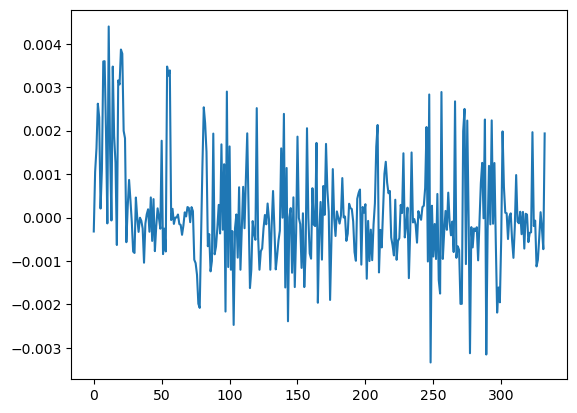

0.004398604722097727


In [107]:
plt.plot(rr.coef_)
plt.show()
print(max(abs(rr.coef_)))

They are small. So we proceed by setting the grid of alpha

In [108]:
alpha_grid = np.logspace(-1, 5, num=50, base=10)
coefs = []

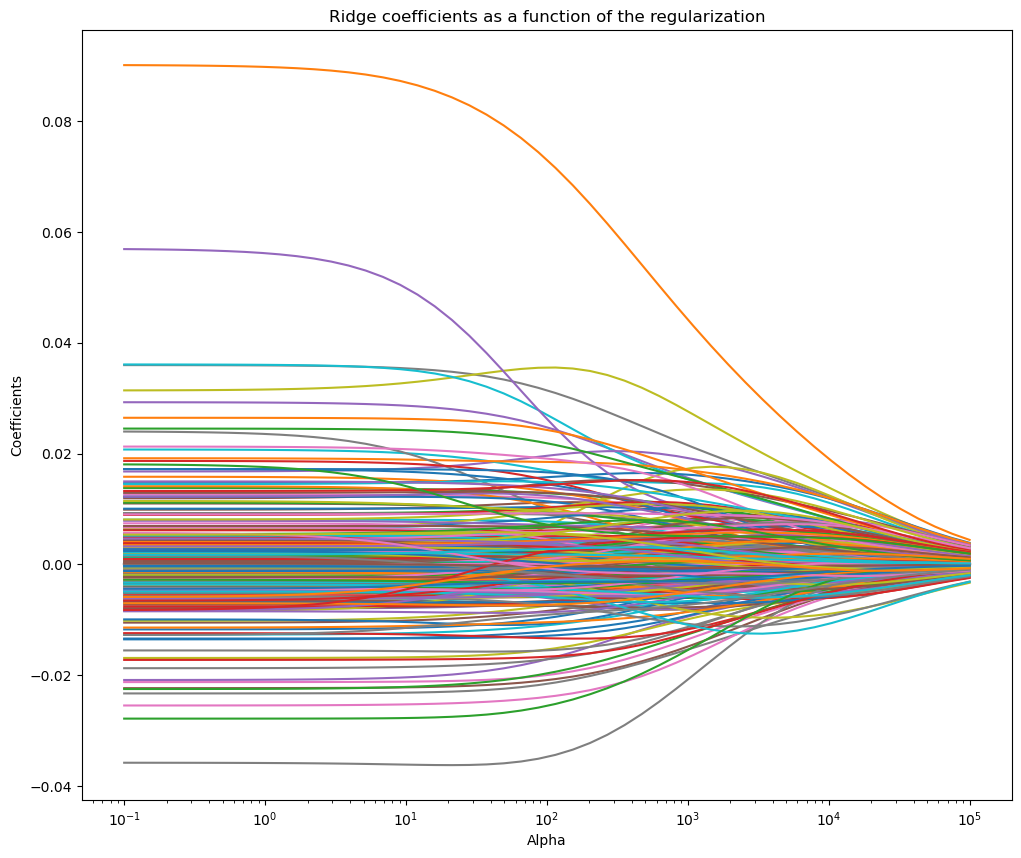

In [109]:
for a in alpha_grid:
    rr = Ridge(alpha=a, fit_intercept=False, random_state=88)
    rr.fit(X_train_rr, y_train)
    coefs.append(rr.coef_)

plt.figure(figsize=(12, 10))
ax = plt.gca()
ax.plot(alpha_grid, coefs)
ax.set_xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Ridge coefficients as a function of the regularization')
plt.show()

### Interpretation of Ridge Coefficient Path

As **alpha** increases, **Ridge** coefficients shrink toward zero; the path plot shows how each coefficient changes with the penalty strength. We next tune alpha via cross-validation to choose a good tradeoff between bias and variance.

### Ridge Hyper-parameter Tuning

In [110]:
alpha_grid = {'alpha': np.logspace(-1, 5, num=50, base=10)}

rr = Ridge(random_state=88)
rr_cv = GridSearchCV(rr, alpha_grid, scoring='neg_mean_squared_error', cv=5)
rr_cv.fit(X_train_rr, y_train)

GridSearchCV(cv=5, estimator=Ridge(random_state=88),
             param_grid={'alpha': array([1.00000000e-01, 1.32571137e-01, 1.75751062e-01, 2.32995181e-01,
       3.08884360e-01, 4.09491506e-01, 5.42867544e-01, 7.19685673e-01,
       9.54095476e-01, 1.26485522e+00, 1.67683294e+00, 2.22299648e+00,
       2.94705170e+00, 3.90693994e+00, 5.17947468e+00, 6.86648845e+00,
       9.10298178e+00, 1.20679264e+01, 1....
       2.68269580e+02, 3.55648031e+02, 4.71486636e+02, 6.25055193e+02,
       8.28642773e+02, 1.09854114e+03, 1.45634848e+03, 1.93069773e+03,
       2.55954792e+03, 3.39322177e+03, 4.49843267e+03, 5.96362332e+03,
       7.90604321e+03, 1.04811313e+04, 1.38949549e+04, 1.84206997e+04,
       2.44205309e+04, 3.23745754e+04, 4.29193426e+04, 5.68986603e+04,
       7.54312006e+04, 1.00000000e+05])},
             scoring='neg_mean_squared_error')

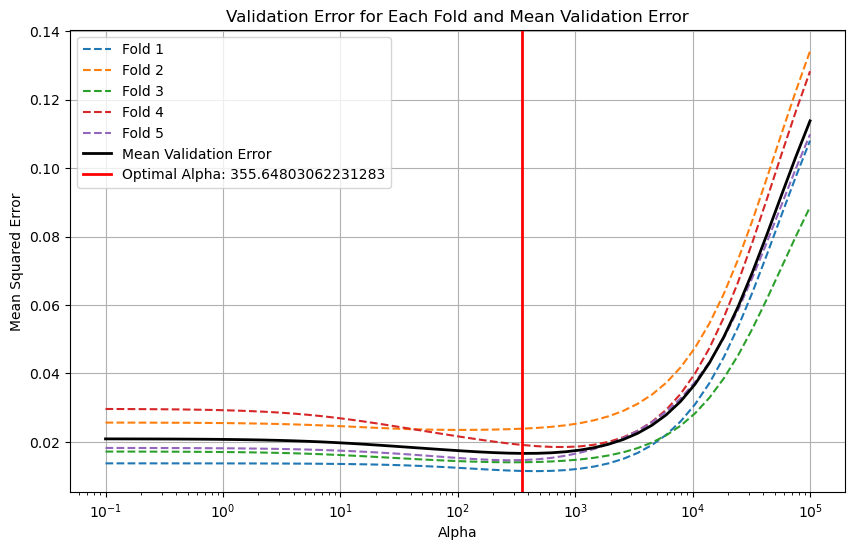

In [111]:

from sklearn.model_selection import GridSearchCV


# Number of CV folds
cv_folds = 5

# Extract alphas and mean test scores
alphas = rr_cv.cv_results_['param_alpha'].data
mean_scores = -rr_cv.cv_results_['mean_test_score']

# Plotting
plt.figure(figsize=(10, 6))

# Plot each fold
for i in range(cv_folds):
    fold_scores = -rr_cv.cv_results_[f'split{i}_test_score']
    plt.plot(alphas, fold_scores, linestyle='--', label=f'Fold {i+1}')

# Plot the mean score
plt.plot(alphas, mean_scores, color='black', label='Mean Validation Error', linewidth=2)

# Mark the optimal alpha
best_alpha = rr_cv.best_params_['alpha']
plt.axvline(x=best_alpha, color='red', linestyle='-', linewidth=2, label=f'Optimal Alpha: {best_alpha}')

# Additional plot settings
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Validation Error for Each Fold and Mean Validation Error')
plt.legend()
plt.grid(True)

# show plot
plt.show()



### Interpretation of Ridge Cross-Validation

Cross-validation selects an optimal **alpha** where the mean squared error is minimized; the plot shows how CV error varies with alpha. **Ridge** with this choice improves out-of-sample performance over OLS by reducing overfitting while retaining all predictors.

## 8. LASSO Regression

**LASSO** uses an L1 penalty and can set some coefficients to exactly zero (sparsity), performing variable selection. We use the same scaled data as for Ridge and tune alpha via cross-validation.

In [112]:
# Same data as Ridge regression
X_train_lasso = X_train_rr
X_test_lasso = X_test_rr

#visualizating the impact of regularization on coeff
#hyperparameter tuning
#not penalize high coef but can reduce to 0
#use same data as regression but save to same variable

In [113]:
alphas = np.logspace(-5, 1 , num=50, base=10)
coefs = []

### Interpretation of LASSO Coefficient Path

As **alpha** increases, some **LASSO** coefficients go to exactly zero (sparsity), unlike **Ridge**, which shrinks all coefficients but keeps them non-zero. The path plot illustrates this variable selection behavior: many coefficients hit zero and remain there as the penalty grows.

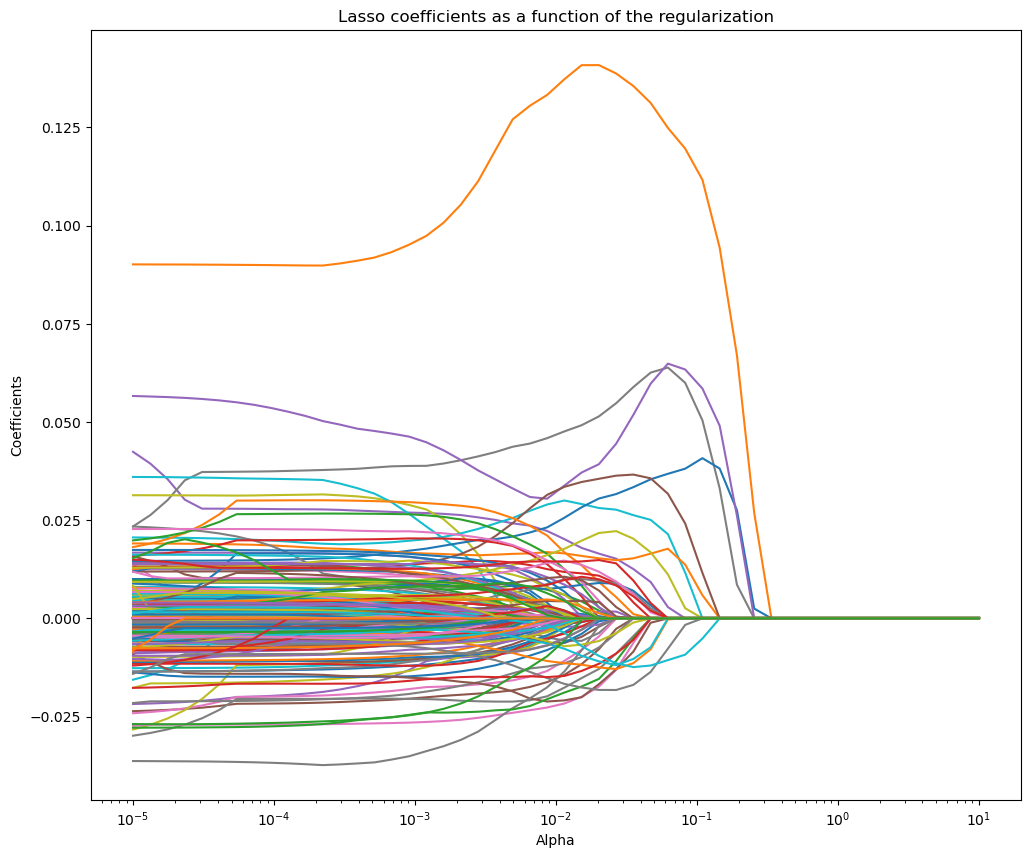

In [114]:
from sklearn.linear_model import Lasso

for a in alphas:
    lasso = Lasso(alpha=a, random_state=88)
    lasso.fit(X_train_lasso, y_train)
    coefs.append(lasso.coef_)

plt.figure(figsize=(12, 10))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso coefficients as a function of the regularization')
plt.show()

In [115]:
alpha_grid = {'alpha': np.logspace(-8, -1, num=50, base=10)}

lasso_cv = GridSearchCV(lasso, alpha_grid, scoring='neg_mean_squared_error', cv=5)
lasso_cv.fit(X_train_lasso, y_train)

GridSearchCV(cv=5, estimator=Lasso(alpha=10.0, random_state=88),
             param_grid={'alpha': array([1.00000000e-08, 1.38949549e-08, 1.93069773e-08, 2.68269580e-08,
       3.72759372e-08, 5.17947468e-08, 7.19685673e-08, 1.00000000e-07,
       1.38949549e-07, 1.93069773e-07, 2.68269580e-07, 3.72759372e-07,
       5.17947468e-07, 7.19685673e-07, 1.00000000e-06, 1.38949549e-06,
       1.93069773e-06, 2.6826...
       1.00000000e-04, 1.38949549e-04, 1.93069773e-04, 2.68269580e-04,
       3.72759372e-04, 5.17947468e-04, 7.19685673e-04, 1.00000000e-03,
       1.38949549e-03, 1.93069773e-03, 2.68269580e-03, 3.72759372e-03,
       5.17947468e-03, 7.19685673e-03, 1.00000000e-02, 1.38949549e-02,
       1.93069773e-02, 2.68269580e-02, 3.72759372e-02, 5.17947468e-02,
       7.19685673e-02, 1.00000000e-01])},
             scoring='neg_mean_squared_error')

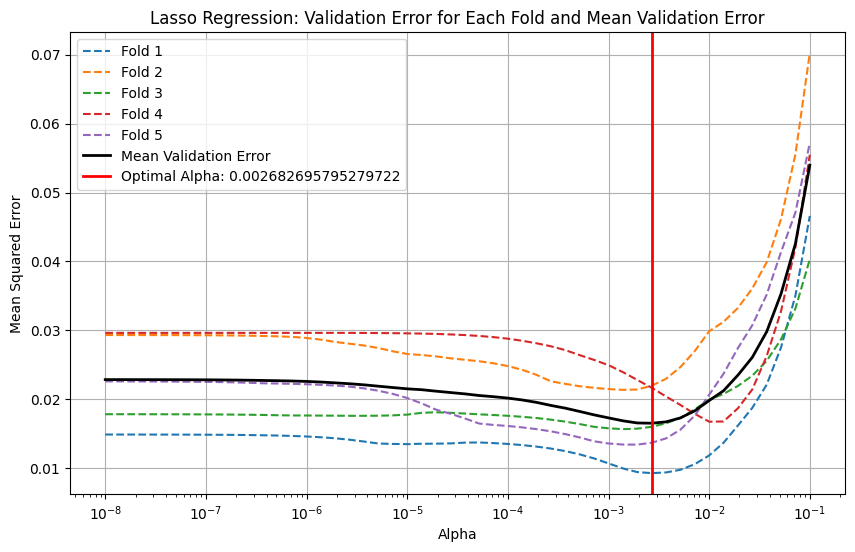

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Assuming your setup for Lasso regression and GridSearchCV is ready and executed:
# alpha_grid = {'alpha': np.logspace(-8, -1, num=50, base=10)}
# lasso = Lasso(random_state=88)
# lasso_cv = GridSearchCV(lasso, alpha_grid, scoring='neg_mean_squared_error', cv=5)
# lasso_cv.fit(X_train_lasso, y_train)

# Extract alphas and mean test scores
alphas = lasso_cv.cv_results_['param_alpha'].data
mean_scores = -lasso_cv.cv_results_['mean_test_score']

# Plotting
plt.figure(figsize=(10, 6))

# Plot each fold
cv_folds = 5
for i in range(cv_folds):
    fold_scores = -lasso_cv.cv_results_[f'split{i}_test_score']
    plt.plot(alphas, fold_scores, linestyle='--', label=f'Fold {i+1}')

# Plot the mean score
plt.plot(alphas, mean_scores, color='black', label='Mean Validation Error', linewidth=2)

# Mark the optimal alpha
best_alpha = lasso_cv.best_params_['alpha']
plt.axvline(x=best_alpha, color='red', linestyle='-', linewidth=2, label=f'Optimal Alpha: {best_alpha}')

# Additional plot settings
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression: Validation Error for Each Fold and Mean Validation Error')
plt.legend()
plt.grid(True)

plt.show()


### Interpretation of LASSO Variable Selection

At the chosen **alpha**, only a subset of features have non-zero coefficients. **LASSO** thus performs variable selection; the number of non-zero coefficients summarizes how many predictors the model actually uses. This can yield a simpler, more interpretable model than Ridge when many features are redundant.

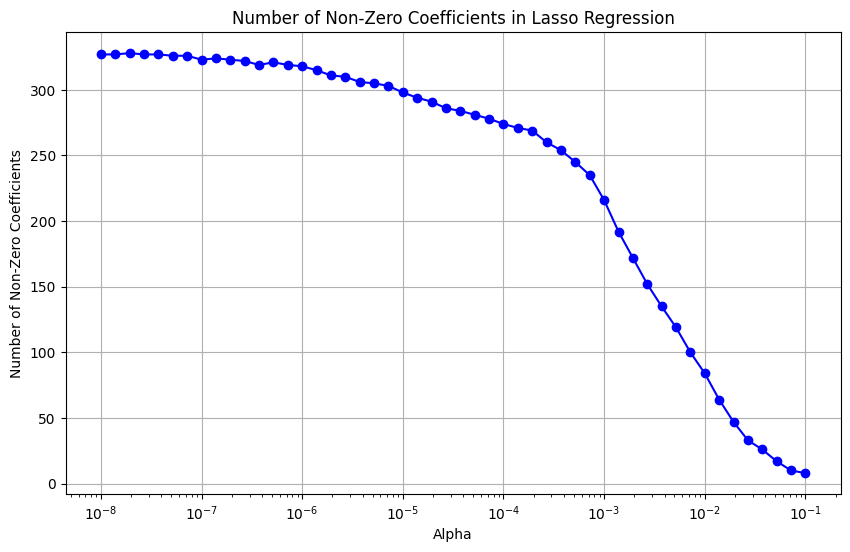

In [62]:
# Extract the alpha values
alphas = lasso_cv.cv_results_['param_alpha'].data

# Initialize a list to store the count of non-zero coefficients
non_zero_coefs = []

# Iterate over the grid search results and count non-zero coefficients for each alpha
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_lasso, y_train)
    non_zero_coefs.append(np.sum(lasso.coef_ != 0))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(alphas, non_zero_coefs, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Number of Non-Zero Coefficients in Lasso Regression')
plt.grid(True)

plt.show()

## 9. Comparison: Best Ridge vs Best LASSO

We report and compare out-of-sample metrics for the best **Ridge** and **LASSO** models chosen by cross-validation.

### Results

In [117]:
best_ridge_model = rr_cv.best_estimator_
best_lasso_model = lasso_cv.best_estimator_
print("Ridge Regression Metrics:")
print_metrics(best_ridge_model, X_train_rr, y_train, X_test_rr, y_test, flag_log_sale_price=True)

print("\nLasso Regression Metrics:")
print_metrics(best_lasso_model, X_train_lasso, y_train, X_test_lasso, y_test, flag_log_sale_price=True)

Ridge Regression Metrics:

Metrics for Log(Sale Price):

Training R2 0.9480367117105497
Training RMSE 0.09195291831876652
Out-of-sample R2 0.8935729705091144
Out-of-sample RMSE 0.13562322593053625

Lasso Regression Metrics:

Metrics for Log(Sale Price):

Training R2 0.9463026243459901
Training RMSE 0.09347462566043241
Out-of-sample R2 0.8929578049099763
Out-of-sample RMSE 0.13601462334989706


### Interpretation of Final Comparison

Both **Ridge** and **LASSO** achieve better test OSR² and lower RMSE than OLS and are comparable to each other. **Ridge** keeps all coefficients but shrinks them toward zero; **LASSO** sets some to exactly zero, giving a sparser model. Either regularized model is a substantial improvement over unregularized OLS for generalization to the test set.

## 10. Summary and Data-Drift Risk

Ridge and LASSO both improve out-of-sample performance over OLS by regularizing the model. This mirrors a broader lesson from Zillow: a model trained on one time period can perform poorly when the market shifts. Linear models are limited in highly volatile or non-stationary settings; monitoring for data drift and retraining are important when deploying such models in production.